## 1. One power spectrum, many realizations

1. No, me espero que sí puedan variar. Si 5 campos, suponiendolos aleatorios, son generados del mismo *power spectrum* $P(k)$, yo me espero que estos campos puedan variar en algunas de sus propiedades, puesto que $P(k)$ está relacionado con la varianza $\sigma$ de la distribución, pero una distribución no está totalmente definida por su $\sigma$.
2. Esperaría que su $\sigma$ y $\mu$ se conserven entre todos los campos, pensando en distribuciones gaussianas, o $\sigma$ y sus variables que dan lugar a la familia concreta de la distribución, por ejemplo.
3. Me esperaría que la amplitud máxima, mínima y la densidad de puntos puedan variar.
4. La amplitud de cada modo estará asociado a qué tan perfecto los puntos aleatorios replican la envolvente de la distribución, $N \to \infty$, así, las amplitudes podrán representar imperfecciones a pequeña escala y sus formas identificables a grandes escalas que identifican a la distribución. La fase debe star relacionado con la posición en el espacio real de la distribución: diferentes fases, diferentes posiciones en el espacio real de la estructura a grandes y pequeñas escalas, es decir, la fase estará relacionada con $\mu$.

### 1.1. Generate five realizations

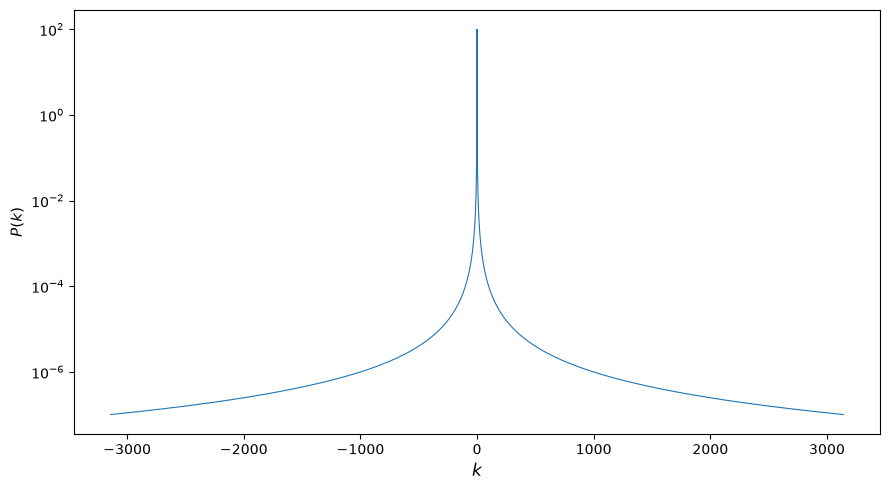

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def P(k, ep):
    n = 1
    d = (np.abs(k) + ep) ** 2
    return n / d

SEED = 42
rng = np.random.default_rng(SEED)

N = 10000 # Samples
lb, rb = 0, 10 # Bounderies
dx = (rb - lb) / (N - 1)

fourier_space_unshifted = 2 * np.pi * np.fft.fftfreq(N, d=dx)
fourier_space = np.fft.fftshift(fourier_space_unshifted)

Pk = P(fourier_space, ep=0.1)

plt.figure(figsize=(9, 5))
plt.plot(fourier_space, Pk, lw=0.8)
plt.yscale('log')
plt.ylabel('$P(k)$', fontsize=11)
plt.xlabel('$k$', fontsize=12)
plt.tight_layout()
plt.show()

rng_childs = rng.spawn(5) # Childs
real_space = np.array([r.normal(lb, rb, N) for r in rng_childs])